In [2]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import IPython.display as ipd
import essentia
import essentia.standard as es
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

In [3]:
FREESOUND_STORE_METADATA_FIELDS = ['id', 'name', 'username', 'previews', 'license', 'tags']

In [7]:
FREESOUND_API_KEY = ""
with open("../fsk.env", "r") as f:
    FREESOUND_API_KEY = f.read().split("=")[1]
    FREESOUND_API_KEY = FREESOUND_API_KEY.replace("\n", "").replace('"','')

client = freesound.FreesoundClient()
client.set_token(FREESOUND_API_KEY)

In [6]:
k = os.getenv('FREESOUND_API_KEY')
client.set_token(k)

In [10]:
from helpers import (
    query_freesound,
    retrieve_sound_preview,
    sounds_to_dataframe,
    delete_dataset_with_gc,
    detect_onsets,
    plot_waveform_with_onsets
)

In [11]:
AUDIO_DIR = "../data/audio/"
META_DIR = "../data/meta/"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

In [12]:
# Queries for THIS RUN
freesound_queries = [
    {
        "query": "running water",
        "filter": None,
        "num_results": 20,
    },
]

In [13]:
# ACTUAL QUERY SCRIPT
# Timestamp to uniquely identify this run
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
meta_csv_path = os.path.join(META_DIR, f"dataset_{timestamp}.csv")
meta_json_path = os.path.join(META_DIR, f"dataset_{timestamp}.json")

# --------------------------------------------------
# Run queries
# --------------------------------------------------
sounds = []
for q in freesound_queries:
    sounds.extend(
        query_freesound(
            query=q["query"],
            filter=q["filter"],
            client=client,
            fs_store_metadata_fields=FREESOUND_STORE_METADATA_FIELDS,
            num_results=q["num_results"],
        )
    )

print(f"Retrieved {len(sounds)} sound metadata objects")

# --------------------------------------------------
# Download previews (idempotent)
# --------------------------------------------------
for i, sound in enumerate(sounds, 1):
    print(f"[{i}/{len(sounds)}] Downloading sound ID {sound.id}")
    retrieve_sound_preview(client, sound, AUDIO_DIR)

# --------------------------------------------------
# Save metadata for THIS RUN ONLY
# --------------------------------------------------
df = sounds_to_dataframe(sounds, AUDIO_DIR)
df.to_csv(meta_csv_path, index=False)
print(f"Saved metadata CSV: {meta_csv_path}")

# --------------------------------------------------
# Save query log
# --------------------------------------------------
query_log = {
    "timestamp": timestamp,
    "num_sounds": len(sounds),
    "queries": freesound_queries,
}

with open(meta_json_path, "w") as f:
    json.dump(query_log, f, indent=2)

print(f"Saved query log JSON: {meta_json_path}")

Retrieved 20 sound metadata objects
[1/20] Downloading sound ID 245225
[2/20] Downloading sound ID 528595
[3/20] Downloading sound ID 674609
[4/20] Downloading sound ID 693588
[5/20] Downloading sound ID 480843
[6/20] Downloading sound ID 34992
[7/20] Downloading sound ID 131469
[8/20] Downloading sound ID 16743
[9/20] Downloading sound ID 347407
[10/20] Downloading sound ID 406230
[11/20] Downloading sound ID 816996
[12/20] Downloading sound ID 384411
[13/20] Downloading sound ID 827443
[14/20] Downloading sound ID 119114
[15/20] Downloading sound ID 382585
[16/20] Downloading sound ID 389464
[17/20] Downloading sound ID 389672
[18/20] Downloading sound ID 832868
[19/20] Downloading sound ID 16744
[20/20] Downloading sound ID 560237
Saved metadata CSV: ../data/meta/dataset_2026-05-01_13-19-37.csv
Saved query log JSON: ../data/meta/dataset_2026-05-01_13-19-37.json


In [14]:
!ls ../data/meta

dataset_2026-01-12_16-08-56.csv   dataset_2026-03-18_18-32-10.json
dataset_2026-01-12_16-08-56.json  dataset_2026-03-18_18-35-35.csv
dataset_2026-01-18_13-58-47.csv   dataset_2026-03-18_18-35-35.json
dataset_2026-01-18_13-58-47.json  dataset_2026-03-18_18-36-36.csv
dataset_2026-01-18_19-06-29.csv   dataset_2026-03-18_18-36-36.json
dataset_2026-01-18_19-06-29.json  dataset_2026-04-30_17-46-52.csv
dataset_2026-01-18_19-30-57.csv   dataset_2026-04-30_17-46-52.json
dataset_2026-01-18_19-30-57.json  dataset_2026-05-01_13-19-37.csv
dataset_2026-03-18_18-32-10.csv   dataset_2026-05-01_13-19-37.json


In [27]:
!cat ../data/meta/dataset_2026-04-30_17-46-52.json

{
  "timestamp": "2026-04-30_17-46-52",
  "num_sounds": 20,
  "queries": [
    {
      "query": "chopping wood",
      "filter": null,
      "num_results": 20
    }
  ]
}

In [9]:
delete_dataset_with_gc(META_DIR + "dataset_2026-01-18_18-29-36.csv", META_DIR, AUDIO_DIR, dry_run=False)

Metadata file not found: /workspace/data/meta/dataset_2026-01-18_18-29-36.csv

GC summary:
  Kept audio files: 129
  Deleted audio files: 0


### Show downloaded audio

In [15]:
!ls -lt ../data/audio | head -20

total 16344
-rw-r--r-- 1 root root 118672 May  1 13:19 560237_12522432-hq.ogg
-rw-r--r-- 1 root root 143805 May  1 13:19 16744_26950-hq.ogg
-rw-r--r-- 1 root root 204555 May  1 13:19 832868_18115820-hq.ogg
-rw-r--r-- 1 root root 146336 May  1 13:19 389672_7158173-hq.ogg
-rw-r--r-- 1 root root 138272 May  1 13:19 389464_6060491-hq.ogg
-rw-r--r-- 1 root root 406622 May  1 13:19 382585_313780-hq.ogg
-rw-r--r-- 1 root root 104316 May  1 13:19 119114_1550701-hq.ogg
-rw-r--r-- 1 root root  46650 May  1 13:19 827443_17908330-hq.ogg
-rw-r--r-- 1 root root 131921 May  1 13:19 384411_5407590-hq.ogg
-rw-r--r-- 1 root root  83310 May  1 13:19 816996_17552599-hq.ogg
-rw-r--r-- 1 root root 168144 May  1 13:19 406230_6068748-hq.ogg
-rw-r--r-- 1 root root 190055 May  1 13:19 347407_6325453-hq.ogg
-rw-r--r-- 1 root root 119743 May  1 13:19 16743_26950-hq.ogg
-rw-r--r-- 1 root root 165502 May  1 13:19 131469_2337088-hq.ogg
-rw-r--r-- 1 root root  42759 May  1 13:19 34992_268901-hq.ogg
-rw-r--r-- 1 root 

In [16]:
# select a file manually
filename = "560237_12522432-hq.ogg"
filename = AUDIO_DIR + filename
filename

'../data/audio/560237_12522432-hq.ogg'

In [19]:
# select a file randomly
filename = random.choice(os.listdir(AUDIO_DIR))
filename = AUDIO_DIR + filename
filename

'../data/audio/664130_14556113-hq.ogg'

/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


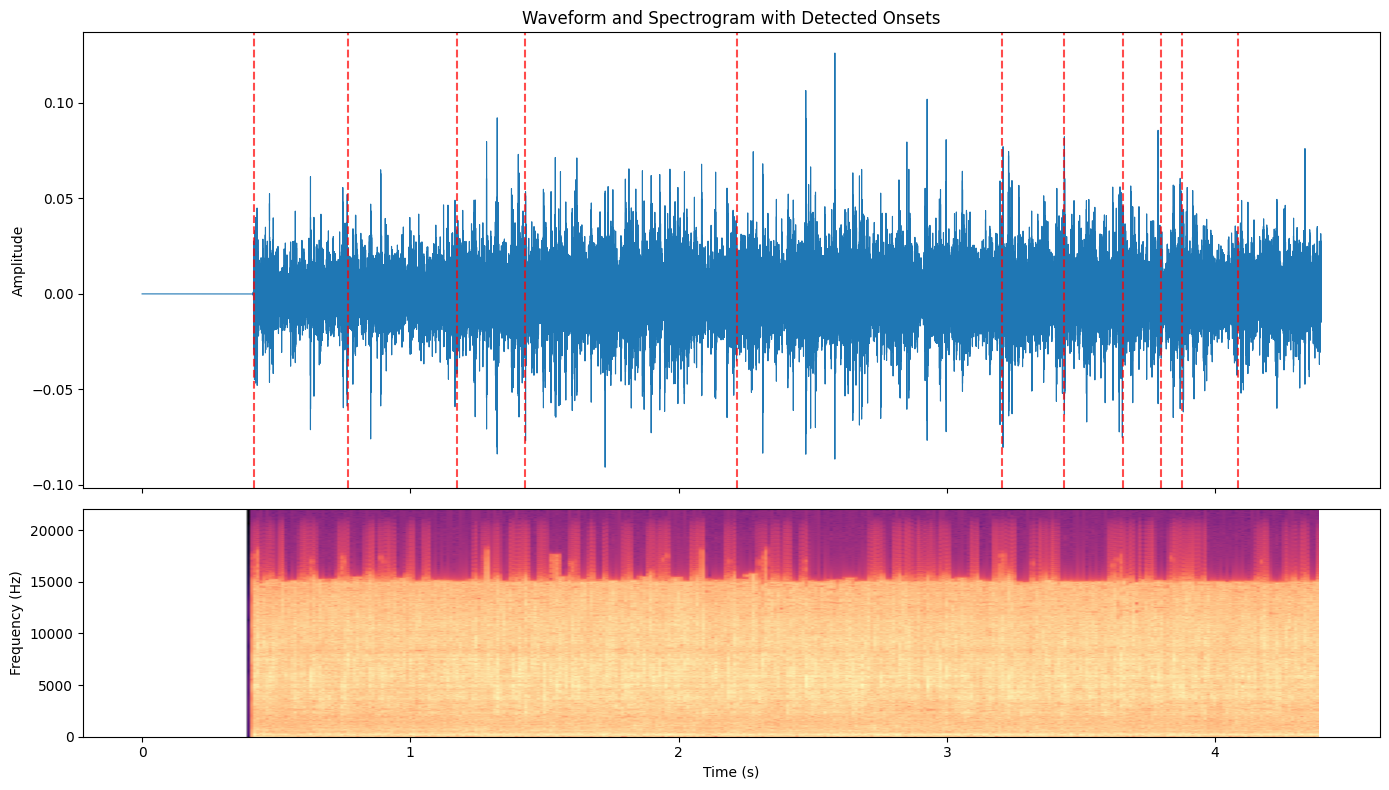

In [17]:
start_time = None
end_time = None
sr = 44100

audio, onset_times = detect_onsets(filename)

plot_waveform_with_onsets(
    audio,
    onset_times,
    sample_rate=sr,
    start_time=start_time,
    end_time=end_time
)

# Audio playback
start_sample = int(start_time * sr) if start_time else 0
end_sample = int(end_time * sr) if end_time else len(audio)-1

ipd.Audio(audio[start_sample:end_sample], rate=sr)